<a href="https://colab.research.google.com/github/abhisar2435/Freelance_Projects_abhisar/blob/main/crop_recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.
Path to dataset files: /kaggle/input/crop-recommendation-dataset


In [ ]:
df=pd.read_csv(path+"/Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
df.label.value_counts(), len(df.label.unique())

(label
 rice           100
 maize          100
 chickpea       100
 kidneybeans    100
 pigeonpeas     100
 mothbeans      100
 mungbean       100
 blackgram      100
 lentil         100
 pomegranate    100
 banana         100
 mango          100
 grapes         100
 watermelon     100
 muskmelon      100
 apple          100
 orange         100
 papaya         100
 coconut        100
 cotton         100
 jute           100
 coffee         100
 Name: count, dtype: int64,
 22)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['label_en']=le.fit_transform(df.label)

In [ ]:
le.classes_

array(['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee',
       'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize',
       'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya',
       'pigeonpeas', 'pomegranate', 'rice', 'watermelon'], dtype=object)

In [ ]:
le

LabelEncoder()

In [ ]:
new_df=df.drop(['label'],axis=1)

In [ ]:
new_df.head()

,N,P,K,temperature,humidity,ph,rainfall,label_en
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20


In [ ]:
le.inverse_transform([1])

array(['banana'], dtype=object)

<Axes: >

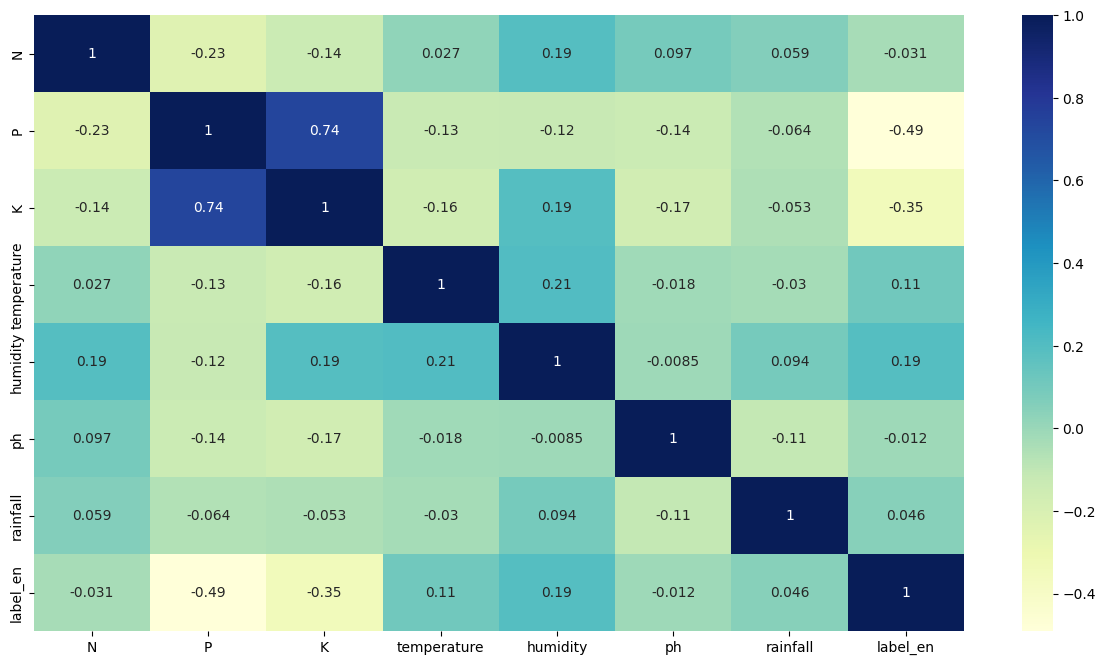

In [ ]:
plt.figure(figsize=(15,8))
sns.heatmap(new_df.corr(),annot=True,cmap="YlGnBu")

In [ ]:
new_df.head()


,N,P,K,temperature,humidity,ph,rainfall,label_en
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20


In [ ]:
x,y=new_df.drop(['label_en'],axis=1),new_df['label_en']


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train,y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
train_data=x_train.join(y_train)
test_data=x_test.join(y_test)
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_s=sc.fit_transform(x_train)
x_test_s=sc.transform(x_test)

In [ ]:
x_test,x_test_s

(        N   P   K  temperature   humidity        ph    rainfall
 269    34  76  80    20.656918  15.845726  7.985417   65.238111
 980    10   5  42    20.241049  91.087068  6.887006  109.253773
 960     1  27  36    23.985988  93.342366  5.684995  104.991282
 1791   56  65  45    38.201682  93.973800  6.751299  218.090881
 185    88  38  15    25.082397  65.921958  6.455117   62.491908
 ...   ...  ..  ..          ...        ...       ...         ...
 1464  111   5  47    28.033065  91.473558  6.274453   21.179248
 277    31  76  82    20.824845  17.850571  7.599280   79.205092
 2098   90  39  43    24.447439  82.286484  6.769346  190.968489
 696     4  44  19    27.956397  83.527060  6.921994   43.257268
 1950  140  40  17    22.727672  77.075981  6.006086   77.551763
 
 [440 rows x 7 columns],
 array([[-0.44096042,  0.69221463,  0.63112396, ..., -2.48644147,
          1.94753771, -0.70188943],
        [-1.09989729, -1.45913067, -0.12167737, ...,  0.88405478,
          0.53703524,  0.

In [ ]:
x_train_s_df = pd.DataFrame(x_train_s, columns=x_train.columns, index=x_train.index)
train_data_s = x_train_s_df.join(y_train)

x_test_s_df = pd.DataFrame(x_test_s, columns=x_test.columns, index=x_test.index)
test_data_s = x_test_s_df.join(y_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train_s,y_train)

LogisticRegression()

In [ ]:
lr.score(x_test_s,y_test)

0.95

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier()
rfc.fit(x_train_s,y_train)
rfc.score(x_test_s,y_test)

0.9931818181818182

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(x_train_s_df, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()
lgbm.fit(x_train_s_df, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000218 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1329
[LightGBM] [Info] Number of data points in the train set: 1760, number of used features: 7
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.116360
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.054228
[LightGBM] [Info] Start training from score -3.018722
[LightGBM] [Info] Start training from score -3.054228
[LightGBM] [Info] Start training from score -3.253561
[LightGBM] [Info] Start training from score -3.103621
[LightGBM] [Info] Start training from score -3.054228
[LightGBM] [Info] Start training from score -3.116360
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.116360
[LightGBM] [Info] Start training from score -3.018722
[LightGBM] 

LGBMClassifier()

In [ ]:
!pip install catboost
from catboost import CatBoostClassifier

cat = CatBoostClassifier(verbose=0)
cat.fit(x_train_s_df, y_train)

CatBoostClassifier(verbose=0)

In [ ]:
xgb_preds = xgb.predict(x_test_s_df)
lgbm_preds = lgbm.predict(x_test_s_df)
cat_preds = cat.predict(x_test_s_df)

# Ensure all predictions are 1D arrays
if xgb_preds.ndim == 2 and xgb_preds.shape[1] == 1:
    xgb_preds = xgb_preds.ravel()
if lgbm_preds.ndim == 2 and lgbm_preds.shape[1] == 1:
    lgbm_preds = lgbm_preds.ravel()
if cat_preds.ndim == 2 and cat_preds.shape[1] == 1:
    cat_preds = cat_preds.ravel()

final_pred = (0.4 * xgb_preds + 0.3 * lgbm_preds + 0.3 * cat_preds)
# Round to the nearest integer and convert to int type for class labels
final_pred = np.round(final_pred).astype(int)

In [ ]:
print("XGB:", xgb.score(x_test_s_df,y_test))
print("LGBM:", lgbm.score(x_test_s_df, y_test))
print("CAT:", cat.score(x_test_s_df,y_test))

XGB: 0.990909090909091
LGBM: 0.9886363636363636
CAT: 0.990909090909091


In [ ]:
print(f'Accuracy of ensemble prediction: {(final_pred == y_test).mean():.4f}')

Accuracy of ensemble prediction: 0.9864


In [ ]:
le.inverse_transform(final_pred)

array(['chickpea', 'pomegranate', 'pomegranate', 'papaya', 'maize',
       'watermelon', 'cotton', 'mungbean', 'lentil', 'banana', 'banana',
       'lentil', 'coffee', 'pomegranate', 'banana', 'apple', 'orange',
       'orange', 'mungbean', 'rice', 'banana', 'pomegranate', 'papaya',
       'lentil', 'kidneybeans', 'coffee', 'coconut', 'jute',
       'pomegranate', 'banana', 'lentil', 'grapes', 'cotton', 'mothbeans',
       'grapes', 'pomegranate', 'chickpea', 'chickpea', 'mothbeans',
       'kidneybeans', 'cotton', 'mango', 'maize', 'pomegranate',
       'watermelon', 'rice', 'maize', 'apple', 'pomegranate', 'mungbean',
       'pigeonpeas', 'cotton', 'pomegranate', 'mothbeans', 'orange',
       'orange', 'kidneybeans', 'papaya', 'lentil', 'maize', 'coconut',
       'rice', 'blackgram', 'jute', 'mothbeans', 'papaya', 'jute',
       'apple', 'grapes', 'mothbeans', 'cotton', 'pomegranate',
       'chickpea', 'papaya', 'papaya', 'cotton', 'watermelon',
       'kidneybeans', 'orange', 'lent

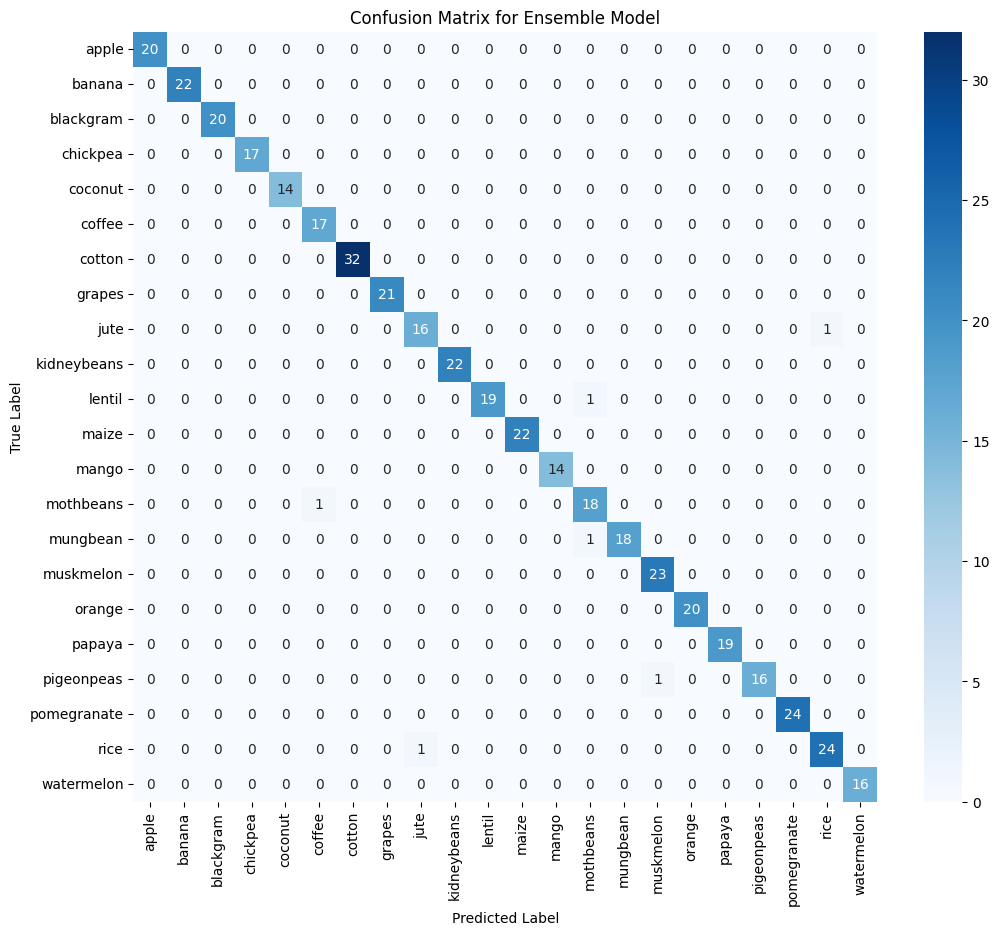

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the confusion matrix
cm = confusion_matrix(y_test, final_pred)

# Get class labels for plotting
class_labels = le.inverse_transform(np.arange(len(le.classes_)))

# Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Ensemble Model')
plt.show()